In [1]:
from pathlib import Path

In [2]:
path = Path("./../dl/4/goog.csv")

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)
df

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400
...,...,...,...,...,...,...
56,3/13/2017,844.000000,848.684998,843.250000,845.539978,1149500
57,3/14/2017,843.640015,847.239990,840.799988,845.619995,779900
58,3/15/2017,847.590027,848.630005,840.770020,847.200012,1379600
59,3/16/2017,849.030029,850.849976,846.130005,848.780029,970400


In [5]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [6]:
data = df.iloc[:, 4:5].values
data

array([[794.200012],
       [796.419983],
       [794.559998],
       [791.26001 ],
       [789.909973],
       [791.549988],
       [785.049988],
       [782.789978],
       [771.820007],
       [786.140015],
       [786.900024],
       [794.02002 ],
       [806.150024],
       [806.650024],
       [804.789978],
       [807.909973],
       [806.359985],
       [807.880005],
       [804.609985],
       [806.070007],
       [802.174988],
       [805.02002 ],
       [819.309998],
       [823.869995],
       [835.669983],
       [832.150024],
       [823.309998],
       [802.320007],
       [796.789978],
       [795.695007],
       [798.530029],
       [801.48999 ],
       [801.340027],
       [806.969971],
       [808.380005],
       [809.559998],
       [813.669983],
       [819.23999 ],
       [820.450012],
       [818.97998 ],
       [824.159973],
       [828.070007],
       [831.659973],
       [830.76001 ],
       [831.330017],
       [828.640015],
       [829.280029],
       [823.2

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

In [8]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
data_sc = sc.fit_transform(data)

In [9]:
import numpy as np

def createSeq(data, seqLen = 3):
    x = []
    y = []

    for i in range(seqLen, len(data)):
        x.append(data[i - seqLen : i])
        y.append(data[i])

    return np.array(x), np.array(y)

In [10]:
x, y = createSeq(data_sc)

In [11]:
x.shape

(58, 3, 1)

In [12]:
y

array([[0.24209223],
       [0.22527981],
       [0.24570341],
       [0.16475695],
       [0.13661236],
       [0.        ],
       [0.17833138],
       [0.18779601],
       [0.27646347],
       [0.42752207],
       [0.43374872],
       [0.41058501],
       [0.44943925],
       [0.43013678],
       [0.44906604],
       [0.4083435 ],
       [0.42652559],
       [0.37801975],
       [0.41344979],
       [0.5914072 ],
       [0.64819422],
       [0.79514303],
       [0.75130792],
       [0.64122041],
       [0.37982571],
       [0.31095859],
       [0.29732258],
       [0.33262797],
       [0.36948926],
       [0.36762172],
       [0.43773312],
       [0.4552927 ],
       [0.4699875 ],
       [0.52117039],
       [0.59053537],
       [0.60560414],
       [0.58729739],
       [0.6518054 ],
       [0.70049824],
       [0.74520517],
       [0.73399766],
       [0.74109613],
       [0.70759672],
       [0.71556701],
       [0.63997538],
       [0.7897882 ],
       [0.73237866],
       [0.713

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

In [15]:
x_train.shape

(46, 3, 1)

In [16]:
model = Sequential([
    layers.Input(shape=(x_train.shape[1], 1)),
    layers.SimpleRNN(50, return_sequences=True),
    layers.Dropout(0.2),
    layers.SimpleRNN(50),
    layers.Dropout(0.2),
    layers.Dense(1)
])

In [17]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
)

In [18]:
model.fit(x_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.6360
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1760
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0719
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1444
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1661
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1041
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0615
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0445
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0852
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1263
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0739
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0320
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0320
Epoch 14/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0789
Epoch 15/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0409
Epoch 16/100
2/2 ━━

In [19]:
predicted_stock_price = model.predict(x_test)

predicted_stock_price = sc.inverse_transform(predicted_stock_price)

real_stock_price = sc.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


In [20]:
import matplotlib.pyplot as plt

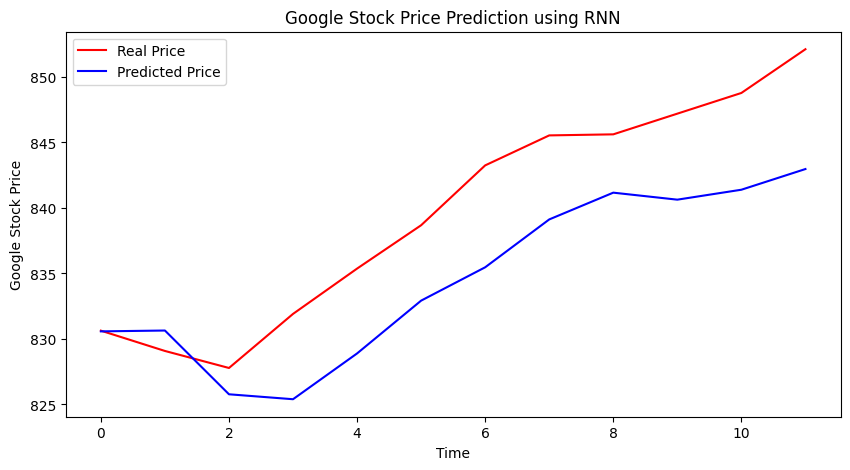

In [21]:
plt.figure(figsize=(10,5))

plt.plot(real_stock_price, color='red', label='Real Price')

plt.plot(predicted_stock_price, color='blue', label='Predicted Price')

plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()


In [22]:
dir(tf.keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']